In [1]:
import os
import sys
sys.path.insert(0,os.path.abspath('../src/'))

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

from topo_edit_util import map_mask, mom6_latlon2ij


In [3]:
path_old = '/glade/campaign/cesm/cesmdata/cseg/inputdata/ocn/mom/tx2_3v2/'
file_old = 'ocean_topo_tx2_3v2_240501.nc'
df_old = xr.open_dataset(path_old+file_old)
df_old

<xarray.Dataset> Size: 21MB
Dimensions:     (lath: 480, lonh: 540, latq: 481, lonq: 541, nEdits: 25)
Coordinates:
  * lath        (lath) float64 4kB -81.56 -81.46 -81.36 ... 89.33 89.6 89.86
  * lonh        (lonh) float64 4kB -286.7 -286.0 -285.3 ... 71.33 72.0 72.67
  * latq        (latq) float64 4kB -81.61 -81.51 -81.41 ... 89.46 89.72 89.91
  * lonq        (lonq) float64 4kB -287.0 -286.3 -285.7 ... 71.67 72.33 73.0
Dimensions without coordinates: nEdits
Data variables: (12/19)
    geolon      (lath, lonh) float64 2MB ...
    geolat      (lath, lonh) float64 2MB ...
    geolonb     (latq, lonq) float64 2MB ...
    geolatb     (latq, lonq) float64 2MB ...
    z           (lath, lonh) float32 1MB ...
    ocn_frac    (lath, lonh) float32 1MB ...
    ...          ...
    orig_mask   (lath, lonh) int32 1MB ...
    D_interp    (lath, lonh) float32 1MB ...
    depth       (lath, lonh) float32 1MB ...
    iEdit       (nEdits) int32 100B ...
    jEdit       (nEdits) int32 100B ...
    zEdit       (nEdits) float64 200B ...
Attributes:
    Description:               Ocean Topography Statistics on MOM6 Grid
    Creator:                   Frank Bryan (bryan@ucar.edu)
    Created:                   20240216
    Generating Code:           create_model_topo.f90
    Model Grid Version:        tx2_3v2
    Source Topography Data:    /glade/campaign/cgd/oce/datasets/obs/SRTM/SRTM...
    Edit History:              Hand Edit + Lake Fill 02/16/2024
    Manual edits updated on::  2024-05-01T15:28:43.496410
    By::                       Gustavo Marques (gmarques@ucar.edu)
    url:                       https://github.com/NCAR/tx2_3/topography/Appen...

In [4]:
file_old = 'topo_edits_tx2_3v2_250107.nc'
df_old_topo_edit = xr.open_dataset(path_old+file_old)
df_old_topo_edit

<xarray.Dataset> Size: 5kB
Dimensions:  (nEdits: 342)
Dimensions without coordinates: nEdits
Data variables:
    iEdit    (nEdits) int32 1kB ...
    jEdit    (nEdits) int32 1kB ...
    ni       int32 4B ...
    nj       int32 4B ...
    zEdit    (nEdits) float64 3kB ...
Attributes:
    title:          Topography Edits
    original grid:  ocean_topo_tx2_3v2_240501.nc
    Edit History:   Date Created 01/07/2025
    history:        Tue Jan  7 15:44:54 2025: ncks -6 topo_edits_tx2_3v2_2501...
    NCO:            netCDF Operators version 5.2.4 (Homepage = http://nco.sf....

In [5]:
nvals = df_old_topo_edit.sizes['nEdits']
for n in range(nvals):
    i = df_old_topo_edit['iEdit'][n].values
    j = df_old_topo_edit['jEdit'][n].values
#    print(i,j,df_old_topo_edit['zEdit'][n].values)
    df_old['depth'][j,i] = df_old_topo_edit['zEdit'][n].values



In [6]:
path_new = '/glade/work/bryan/MOM6-data-files/Topography/tx2_3v3_Feb2026/'
file_new = 'topo.sub150.tx2_3v3.SRTM15_V2.4.edit2.SmL1.0_C1.0.nc'
df_new = xr.open_dataset(path_new+file_new)

In [7]:
df_new

<xarray.Dataset> Size: 21MB
Dimensions:     (lath: 480, lonh: 540, latq: 481, lonq: 541, nEdits: 367)
Coordinates:
  * lath        (lath) float64 4kB -81.56 -81.46 -81.36 ... 89.33 89.6 89.86
  * lonh        (lonh) float64 4kB -286.7 -286.0 -285.3 ... 71.33 72.0 72.67
  * latq        (latq) float64 4kB -81.61 -81.51 -81.41 ... 89.46 89.72 89.91
  * lonq        (lonq) float64 4kB -287.0 -286.3 -285.7 ... 71.67 72.33 73.0
Dimensions without coordinates: nEdits
Data variables: (12/19)
    geolon      (lath, lonh) float64 2MB ...
    geolat      (lath, lonh) float64 2MB ...
    geolonb     (latq, lonq) float64 2MB ...
    geolatb     (latq, lonq) float64 2MB ...
    z           (lath, lonh) float32 1MB ...
    ocn_frac    (lath, lonh) float32 1MB ...
    ...          ...
    orig_mask   (lath, lonh) int32 1MB ...
    D_interp    (lath, lonh) float32 1MB ...
    D_edit2     (lath, lonh) float32 1MB ...
    iEdit       (nEdits) int32 1kB ...
    jEdit       (nEdits) int32 1kB ...
    zEdit       (nEdits) float64 3kB ...
Attributes:
    Description:             Ocean Topography Statistics on MOM6 Grid
    Creator:                 Frank Bryan
    Created:                 20260226
    Generating Code:         create_model_topo.f90
    Model Grid Version:      tx2_3v3
    Source Topography Data:  /glade/work/bryan/Observations/Topography/SRTM/S...
    Edit History:            Hand Edit + Lake Fill 02/27/2026

In [8]:
path_model = '/glade/derecho/scratch/gmarques/archive/b.e30_alpha07g.B1850C_LTso.ne30_t232_wgx3.304/ocn/hist/'
file_model = 'b.e30_alpha07g.B1850C_LTso.ne30_t232_wgx3.304.mom6.h.ocean_geometry.nc'
df_model = xr.open_dataset(path_model+file_model)
df_model

<xarray.Dataset> Size: 48MB
Dimensions:  (latq: 480, lonq: 540, lath: 480, lonh: 540)
Coordinates:
  * latq     (latq) float64 4kB -81.51 -81.41 -81.31 ... 87.68 87.73 87.74
  * lonq     (lonq) float64 4kB -286.3 -285.7 -285.0 -284.3 ... 71.67 72.33 73.0
  * lath     (lath) float64 4kB -81.56 -81.46 -81.36 ... 87.65 87.71 87.74
  * lonh     (lonh) float64 4kB -286.7 -286.0 -285.3 -284.7 ... 71.33 72.0 72.67
Data variables: (12/23)
    geolatb  (latq, lonq) float64 2MB ...
    geolonb  (latq, lonq) float64 2MB ...
    geolat   (lath, lonh) float64 2MB ...
    geolon   (lath, lonh) float64 2MB ...
    geolatu  (lath, lonq) float64 2MB ...
    geolonu  (lath, lonq) float64 2MB ...
    ...       ...
    dyBu     (latq, lonq) float64 2MB ...
    Ah       (lath, lonh) float64 2MB ...
    Aq       (latq, lonq) float64 2MB ...
    dxCvo    (latq, lonh) float64 2MB ...
    dyCuo    (lath, lonq) float64 2MB ...
    wet      (lath, lonh) float64 2MB ...
Attributes:
    NumFilesInSet:  1

In [9]:
MAX_DEPTH = 6000.
MIN_DEPTH = 9.5
depth_old_clipped = df_old['depth']
depth_old_clipped = xr.where(depth_old_clipped > MAX_DEPTH,MAX_DEPTH,depth_old_clipped)
#depth_old_clipped = xr.where(depth_old_clipped < MIN_DEPTH,MIN_DEPTH,depth_old_clipped)
diff = df_model['D'] - depth_old_clipped
print('Model depth min error = ',diff.min().values,' max error = ',diff.max().values)

Model depth min error =  0.0  max error =  0.0


In [10]:
diff = df_old['mask'] - df_new['mask']
x = diff.where(diff != 0,drop=True).stack(grid=('lath','lonh'))
print('# of mask values changed = ',x.count().values,' min change=',x.min().values,' max change=',x.max().values)

# of mask values changed =  30  min change= 1.0  max change= 1.0


In [11]:
diff = df_old['D_interp'] - df_new['D_interp']
x = diff.where(np.abs(diff) > 0.01,drop=True).stack(grid=('lath','lonh'))
print('# of uneditted depths changed by > 1 cm = ',x.count().values,' min change=',x.min().values,' max change=',x.max().values)

# of uneditted depths changed by > 1 cm =  30  min change= 10.16926097869873  max change= 888.458740234375


In [12]:
diff = df_old['depth'] - df_new['D_edit2']
x = diff.where(np.abs(diff) > 0.01,drop=True).stack(grid=('lath','lonh'))
print('# of depths changed by > 1 cm = ',x.count().values,' min change=',x.min().values,' max change=',x.max().values)

# of depths changed by > 1 cm =  30  min change= 10.16926097869873  max change= 888.458740234375


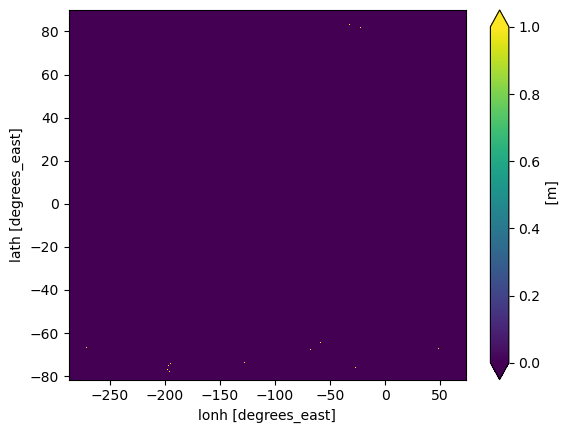

In [14]:
diff.plot(robust=True,vmin=0,vmax=1)

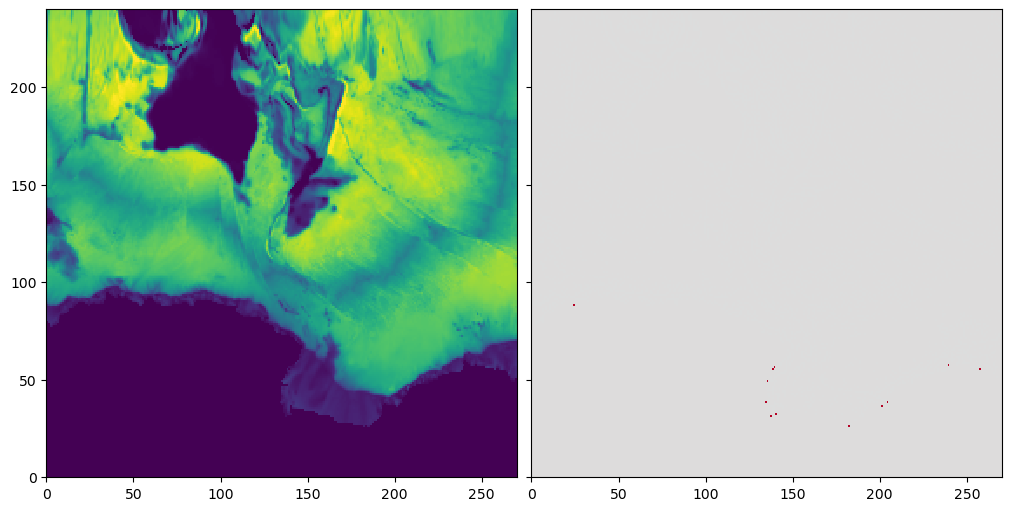

In [15]:
fig,ax=plt.subplots(ncols=2,sharex=True,sharey=True,figsize=(10,5),constrained_layout=True)

ax[0].pcolormesh(df_old['depth'],cmap='viridis',vmin=0,vmax=6000)
ax[0].set_xlim(0,270)
ax[0].set_ylim(0,240)
ax[1].pcolormesh((df_old['depth'] - df_new['D_edit2']),vmin=-1,vmax=1,cmap='coolwarm')

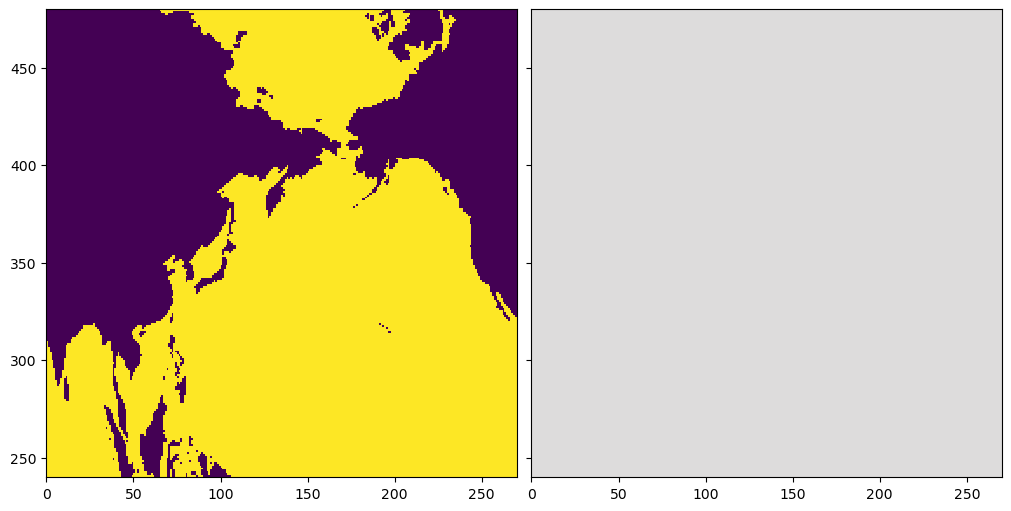

In [16]:
fig,ax=plt.subplots(ncols=2,sharex=True,sharey=True,figsize=(10,5),constrained_layout=True)

ax[0].pcolormesh(df_new['mask'],cmap='viridis',vmin=0,vmax=1)
ax[0].set_xlim(0,270)
ax[0].set_ylim(240,480)
ax[1].pcolormesh((df_old['mask'] - df_new['mask']),vmin=-1,vmax=1,cmap='coolwarm')

In [ ]:
fig,ax=plt.subplots(ncols=2,sharex=True,sharey=True,figsize=(10,5),constrained_layout=True)

ax[0].pcolormesh(df_new['mask'],cmap='viridis',vmin=0,vmax=1)
ax[0].set_xlim(270,540)
ax[0].set_ylim(0,240)
ax[1].pcolormesh((df_old['mask'] - df_new['mask']),vmin=-1,vmax=1,cmap='coolwarm')

In [ ]:
fig,ax=plt.subplots(ncols=2,sharex=True,sharey=True,figsize=(10,5),constrained_layout=True)

ax[0].pcolormesh(df_new['mask'],cmap='viridis',vmin=0,vmax=1)
ax[0].set_xlim(270,540)
ax[0].set_ylim(240,480)
ax[1].pcolormesh((df_old['mask'] - df_new['mask']),vmin=-1,vmax=1,cmap='coolwarm')

In [ ]:
fig,ax=plt.subplots(ncols=2,sharex=True,sharey=True,figsize=(10,5),constrained_layout=True)

ax[0].pcolormesh(df_new['mask'],cmap='viridis',vmin=0,vmax=1)
ax[0].set_xlim(0,279)
ax[0].set_ylim(240,480)
ax[1].pcolormesh((df_old['mask'] - df_new['mask']),vmin=-1,vmax=1,cmap='coolwarm')

In [ ]:
fig,ax=plt.subplots(ncols=2,sharex=True,sharey=True,figsize=(10,5),constrained_layout=True)

ax[0].pcolormesh(df_old['D_mean'],cmap='viridis')
ax[1].pcolormesh((df_old['D_mean'] - df_new['D_mean']),cmap='coolwarm',vmin=-1,vmax=1)

print(np.max(np.abs((df_old['D_mean'] - df_new['D_mean']).values)))

In [ ]:
fig,ax=plt.subplots(ncols=2,sharex=True,sharey=True,figsize=(10,5),constrained_layout=True)

ax[0].pcolormesh(df_old['D_interp'],cmap='viridis')
ax[1].pcolormesh((df_old['D_interp'] - df_new['D_interp']),cmap='coolwarm',vmin=-1,vmax=1)

print(np.max(np.abs((df_old['D_interp'] - df_new['D_interp']).values)))